# Diurnal Cycle of Lightning and Overshooting Tops: Land vs Ocean (Warm Season)

Purpose: Compares the diurnal cycle of lightning and overshooting-top (OT) detections
during the warm season (Oct–Apr) over Northern Australia, segregated by land and ocean
surface type, to characterize differences in the timing of activity across surface types. 

Input:
- OT land/ocean detection dataframes (2016–2024, whole Australia; subset here to
  Northern Australia region)
- Lightning land/ocean detection dataframes (2016–2024, UTC)
- Derived from raw OT and lightning detection products via the companion notebooks
  03_process_OT_land_ocean_split_2015_2025.ipynb and 04_lightning_land_ocean_split_2016_2024.ipynb

Processing: Filters both datasets to the Northern Australia region and warm-season
months, aggregates detection counts by hour of day (land, ocean, and combined), and
normalizes by the number of warm seasons in the record.

Output: A 2x3 panel figure comparing diurnal histograms of lightning (top row) and OT
(bottom row) detections, by surface type (whole / land / ocean), saved as
warm_season_diurnal_per_year_plot.png.

In [4]:
import xarray as xr
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import matplotlib.colors as colors
import os
import glob
import xesmf as xe
import intake


In [1]:
def select_warm_season(df):
    """
    selecting warm season months
    """

    return df[
        (df["lat"] >= LAT_MIN) &
        (df["lat"] <= LAT_MAX) &
        (df["lon"] >= LON_MIN) &
        (df["lon"] <= LON_MAX) &
        (df["time"].dt.month.isin([10, 11, 12, 1, 2, 3, 4]))
    ]


def aggregate_by_hour(var ,**dataframes):
    """
    aggregrating by hours 
    """
    results = {
        name: df.assign(hour=pd.to_datetime(df['time']).dt.hour)
                .groupby('hour')[var]
                .sum()
        for name, df in dataframes.items()
    }
    results['combined'] = sum(results.values())
    return results

In [3]:
land_ot = pd.read_feather("/g/data/if69/tp4064/Project_1/OT/dataframe_LAND_OT/"+
                    "whole_Australia_LAND_OT_2016_2024.feather").rename(columns={"UTC_time": "time"})

ocean_ot = pd.read_feather("/g/data/if69/tp4064/Project_1/OT/dataframe_OCEAN_OT/"+
                        "whole_Australia_OCEAN_OT_2016_2024.feather").rename(columns={"UTC_time": "time"})

land_lightning = pd.read_csv("/g/data/if69/tp4064/Project_1/Lightning/code_not_renewed_land_lightning.csv",
                            usecols = ['lat','lon','time','lightning_count'],
                            parse_dates=["time"])

ocean_lightning = pd.read_csv("/g/data/if69/tp4064/Project_1/Lightning/code_not_renewed_ocean_lightning.csv",
                             usecols = ['lat','lon','time','lightning_count'],
                            parse_dates=["time"])

LAT_MAX=-10
LAT_MIN=-20
LON_MIN=120
LON_MAX=148

In [6]:
OT = {
    'land':select_warm_season(land_ot),
    'ocean':select_warm_season(ocean_ot)
}

lightning = {
    'land' : select_warm_season(land_lightning),
    'ocean': select_warm_season(ocean_lightning)
}

results_ot = aggregate_by_hour(var = 'ot_probability', **OT)
results_lightning = aggregate_by_hour(var = 'lightning_count', **lightning)

results_ot['land'] = results_ot['land']/8  # 8 total warm season for 9 years
results_ot['ocean'] = results_ot['ocean']/8s
results_ot['combined'] = results_ot['combined']/8

results_lightning['land'] = results_lightning['land']/8
results_lightning['ocean'] = results_lightning['ocean']/8
results_lightning['combined'] = results_lightning['combined']/8

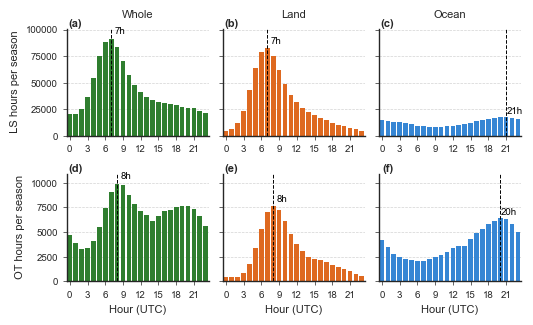

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# ----------------------
# Dark GRL-style colors
# ----------------------
colors_ls = ["#228B22", "#FE6100", "#1C86EE"]    # Dark red, green, blue
colors_ot = ["#228B22", "#FE6100", "#1C86EE"]  

# ----------------------
# Seaborn style
# ----------------------
sns.set_style("white")
sns.set_context("paper", font_scale=0.7)

# ----------------------
# Figure setup
# ----------------------
fig, axes = plt.subplots(2, 3, figsize=(5.5, 3.5), sharey=False)
plt.subplots_adjust(hspace=0.35, wspace=0.08)
axes = axes.flatten()

# ----------------------
# Row 1: Lightning
# ----------------------
for i, data in enumerate([results_lightning['combined'], results_lightning['land'], results_lightning['ocean']]):
    sns.barplot(x=data.index, y=data.values, ax=axes[i], color=colors_ls[i], edgecolor=None, linewidth=0.0)

    # Find peak hour and value
    peak_hour = data.idxmax()
    peak_val = data.max()
    peak_pos = list(data.index).index(peak_hour)  # x-position on categorical axis
    
    # Vertical line at peak
    axes[i].axvline(peak_pos, color='k', linestyle='dashed', linewidth=0.7)
    
    # Optional: annotate the peak hour above the line
    axes[i].text(peak_pos+1.5, peak_val * 1.03, f"{peak_hour}h", 
                 fontsize=7, ha='center', va='bottom', color='k')

# Row 2: Overshooting Tops
for i, data in enumerate([results_ot['combined'], results_ot['land'], results_ot['ocean']]):
    sns.barplot(x=data.index, y=data.values, ax=axes[i+3], color=colors_ot[i], edgecolor=None, linewidth=0.0)

    peak_hour = data.idxmax()
    peak_val = data.max()
    peak_pos = list(data.index).index(peak_hour)
    
    axes[i+3].axvline(peak_pos, color='k', linestyle='dashed', linewidth=0.7)
    axes[i+3].text(peak_pos+1.5, peak_val * 1.03, f"{peak_hour}h", 
                   fontsize=7, ha='center', va='bottom', color='k')

# ----------------------
# Adjust ylim for top row (Lightning)
# ----------------------
top_max = max([max(results_lightning['combined']), max(results_lightning['land']), max(results_lightning['ocean'])]) * 1.1
for i in range(3):  # axes 0,1,2
    axes[i].set_ylim(0, top_max)

# ----------------------
# Adjust ylim for bottom row (Overshooting Tops)
# ----------------------
bottom_max = max([max(results_ot['combined']), max(results_ot['land']), max(results_ot['ocean'])]) * 1.1
for i in range(3, 6):  # axes 3,4,5
    axes[i].set_ylim(0, bottom_max)

# ----------------------
# Hide y-ticks and labels in 2nd and 3rd columns
# ----------------------
for i in [1, 2, 4, 5]:  # axes 1,2 (top row) and 4,5 (bottom row)
    # axes[i].set_yticks([])       # remove tick marks
    axes[i].set_yticklabels([])  # remove labels
    axes[i].set_ylabel(None) 
    
    
# ----------------------
# Column titles
# ----------------------
axes[0].set_title("Whole", fontsize=8, pad=8)
axes[1].set_title("Land", fontsize=8, pad=8)
axes[2].set_title("Ocean", fontsize=8, pad=8)

# ----------------------
# Remove top/right spines
# ----------------------
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ----------------------
# Axes ticks for all subplots
# ----------------------
for i, ax in enumerate(axes):
    ax.set_xticks(np.arange(0, 24, 3))
    # ax.set_yticks(None)  # will show numbers automatically
    ax.tick_params(axis='both', labelsize=7, direction='out', length=3, width=0.5,
                bottom=True, left=True)

    # Horizontal grid
    ax.yaxis.grid(True, color='lightgray', linestyle='--', linewidth=0.5)
    ax.xaxis.grid(False)

# Labels
for i, ax in enumerate(axes):
    if i == 0:
        ax.set_ylabel(" LS hours per season", fontsize=8)
    if i == 3:
        ax.set_ylabel(" OT hours per season", fontsize=8)
    if i >= 3:
        ax.set_xlabel("Hour (UTC)", fontsize=8)
    if i < 3 :
        ax.xaxis.label.set_visible(False)
        

# ----------------------
# Panel labels (a–f) above axes
# ----------------------
for i, ax in enumerate(axes):
    ax.text(0.06, 1, f"({chr(97+i)})", transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='bottom', ha='center')

# ----------------------
# Row labels (left side)
# ----------------------
# fig.text(0.02, 0.78, "Lightning", va='center', rotation='vertical', fontsize=9)
# fig.text(0.02, 0.28, "Overshooting Tops", va='center', rotation='vertical', fontsize=9)

# ----------------------
# Save & show
# ----------------------
plt.tight_layout(rect=[0.03, 0, 1, 0.93])
plt.savefig("/g/data/if69/tp4064/Project_1/Plots/warm_season/warm_season_diurnal_per_year_plot.png", dpi=400)
plt.show()